In [ ]:
# Import necessary libraries

# Data Manipulation
import pandas as pd
import numpy as np
import chardet

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# Network Analysis
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 1. Data Loading and Initial Cleaning

In [ ]:
print("--- 1. Data Loading and Initial Cleaning ---")

# Guess encoding of the file
file_path = 'air-bnb-listings_USA.csv'
with open(file_path, "rb") as f:
    raw_data = f.read(100000) 
    guess = chardet.detect(raw_data)
    print(f"Detected encoding: {guess}")
    df = pd.read_csv(file_path, encoding=guess['encoding'])

print(f"Original data shape: {df.shape}")



# Drop columns that are not needed
columns_to_drop = ['Name', 'Number of reviews', 'Date last review', 'Updated Date', 'Coordinates']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Drop rows with missing values
df_cleaned = df_cleaned.dropna()

# Drop rows with price less than 10
df_cleaned = df_cleaned[df_cleaned['Room Price']  >= 10]

# Remove availability less than 10
df_cleaned = df_cleaned[df_cleaned['Availibility'] >= 10]

# Drop with Number of reviews per month = 0
df_cleaned = df_cleaned[df_cleaned['Number of reviews per month'] != 0]

# Unique values for Room type
print(f"Unique values in 'Room type': {df_cleaned['Room type'].unique()}")

--- 1. Data Loading and Initial Cleaning ---
Detected encoding: {'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}
Original data shape: (240665, 17)
Unique values in 'Room type': ['Entire home/apt' 'Private room' 'Hotel room' 'Shared room']


## 2. Feature Engineering and Preprocessing for Clustering

In [ ]:
features_for_clustering_raw = [
    'Room Price', 
    'Minimum nights',
    'Rooms rent by the host', 
    'Room type'
]

# Convert room type into numeric values 'Entire home/apt' 'Private room' 'Hotel room' 'Shared room'
room_type_mapping = {
    'Entire home/apt': 0,
    'Private room': 1,
    'Hotel room': 2,
    'Shared room': 3
}
df_cleaned['Room type'] = df_cleaned['Room type'].map(room_type_mapping)

# Select features for clustering
features_for_clustering = [feature for feature in features_for_clustering_raw if feature in df_cleaned.columns]
# Create a new DataFrame with selected features
df_cluster = df_cleaned[features_for_clustering].copy()



\n--- 2a. Feature Engineering and Preprocessing for Clustering ---
\n--- 3. Price and Room Type ---


## 3. Feature Engineering and Preprocessing for Clustering

Shape of X_cluster after dropna: (138205, 4)
Data scaled. Shape of X_scaled: (138205, 4)
Applied weight 1 to 'Room Price'
Applied weight 1 to 'Minimum nights'
Applied weight 2 to 'Rooms rent by the host'
Applied weight 1 to 'Room type'
\n--- 3a. K-Means Clustering ---


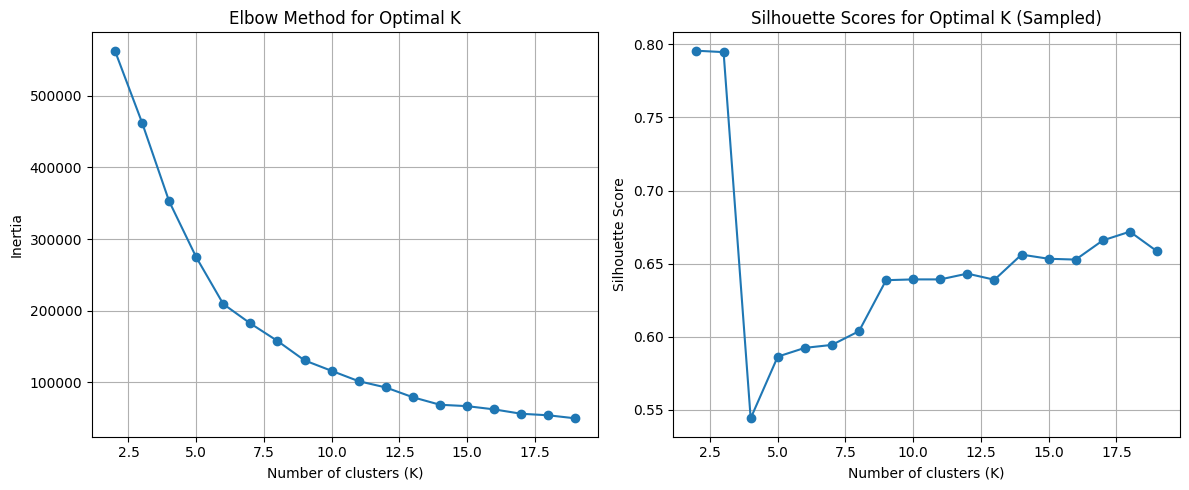

In [ ]:
X_cluster = df_cluster.copy()

X_cluster.dropna(inplace=True)
print(f"Shape of X_cluster after dropna: {X_cluster.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f"Data scaled. Shape of X_scaled: {X_scaled.shape}")


#  Feature Weights 

feature_weights = {
    'Room Price': 1,               
    'Minimum nights': 1,           
    'Rooms rent by the host': 2,   
    'Room type': 1                 
}

X_scaled = X_scaled.copy()

for i, col in enumerate(X_cluster.columns):
    if col in feature_weights:
        X_scaled[:, i] *= feature_weights[col]
        print(f"Applied weight {feature_weights[col]} to '{col}'")


inertia = []
silhouette_scores = []


k_range = range(2, 20)

silhouette_sample_size = 4000

for k_val in k_range:

    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled) # Fit and get labels
    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(X_scaled, labels, sample_size=silhouette_sample_size, random_state=42)
    silhouette_scores.append(score)

# Plot Elbow method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
valid_k_for_inertia = [k for i, k in enumerate(k_range) if not np.isnan(inertia[i])]
valid_inertia = [i for i in inertia if not np.isnan(i)]
if valid_k_for_inertia:
    plt.plot(valid_k_for_inertia, valid_inertia, marker='o')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Inertia')
    plt.grid(True)
else:
    print("No valid inertia values to plot.")

plt.subplot(1, 2, 2)
valid_k_for_silhouette = [k for i, k in enumerate(k_range) if silhouette_scores[i] != -1 and not np.isnan(silhouette_scores[i])]
valid_silhouette_scores = [s for s in silhouette_scores if s != -1 and not np.isnan(s)]

if valid_k_for_silhouette:
    plt.plot(valid_k_for_silhouette, valid_silhouette_scores, marker='o')
    plt.title('Silhouette Scores for Optimal K (Sampled)')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
else:
    print("Could not plot Silhouette scores (not enough valid scores or all resulted in errors).")

plt.tight_layout()
plt.show()

In [ ]:
# k 4 might not look the mostr optimal, but it is the most stable

k_optimal = 4
print(f"Running K-Means with chosen K = {k_optimal}")

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
kmeans_final.fit(X_scaled)
df_cluster['KMeans_Cluster'] = kmeans_final.labels_


Running K-Means with chosen K = 4


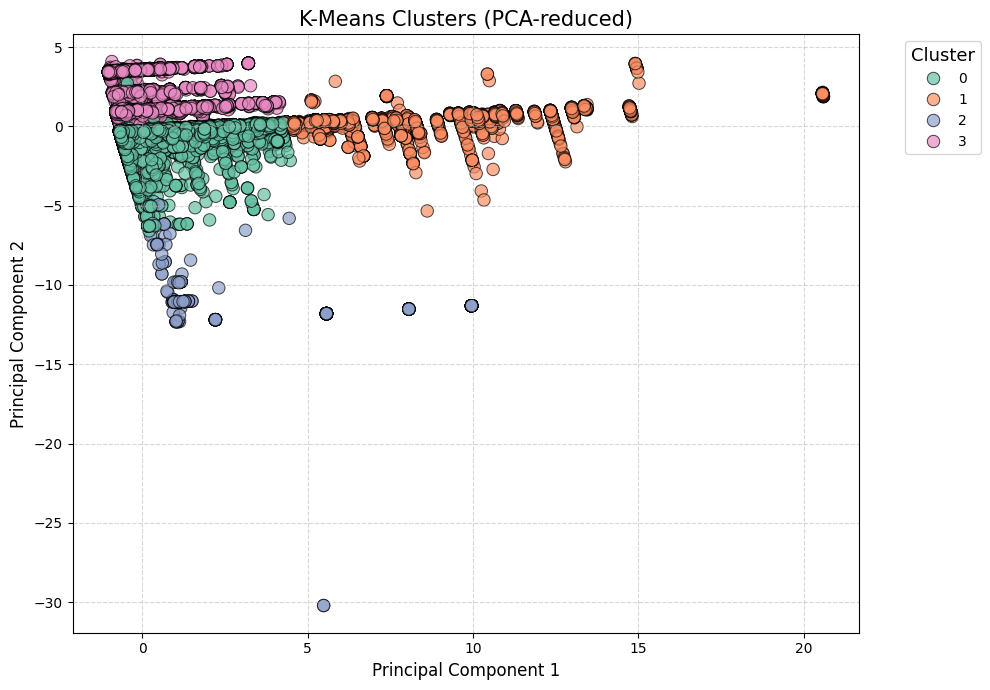

In [6]:
pca = PCA(n_components=2, random_state=42)
df_visual = df_cluster.copy()
df_visual[['PCA1', 'PCA2']] = pca.fit_transform(X_scaled)

# Plotting K-Means Clusters with PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='KMeans_Cluster', 
    palette='Set2', 
    data=df_visual,
    s=80, 
    alpha=0.7,
    edgecolor='k'
)

plt.title('K-Means Clusters (PCA-reduced)', fontsize=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', loc='best', bbox_to_anchor=(1.05, 1), fontsize=10, title_fontsize='13')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

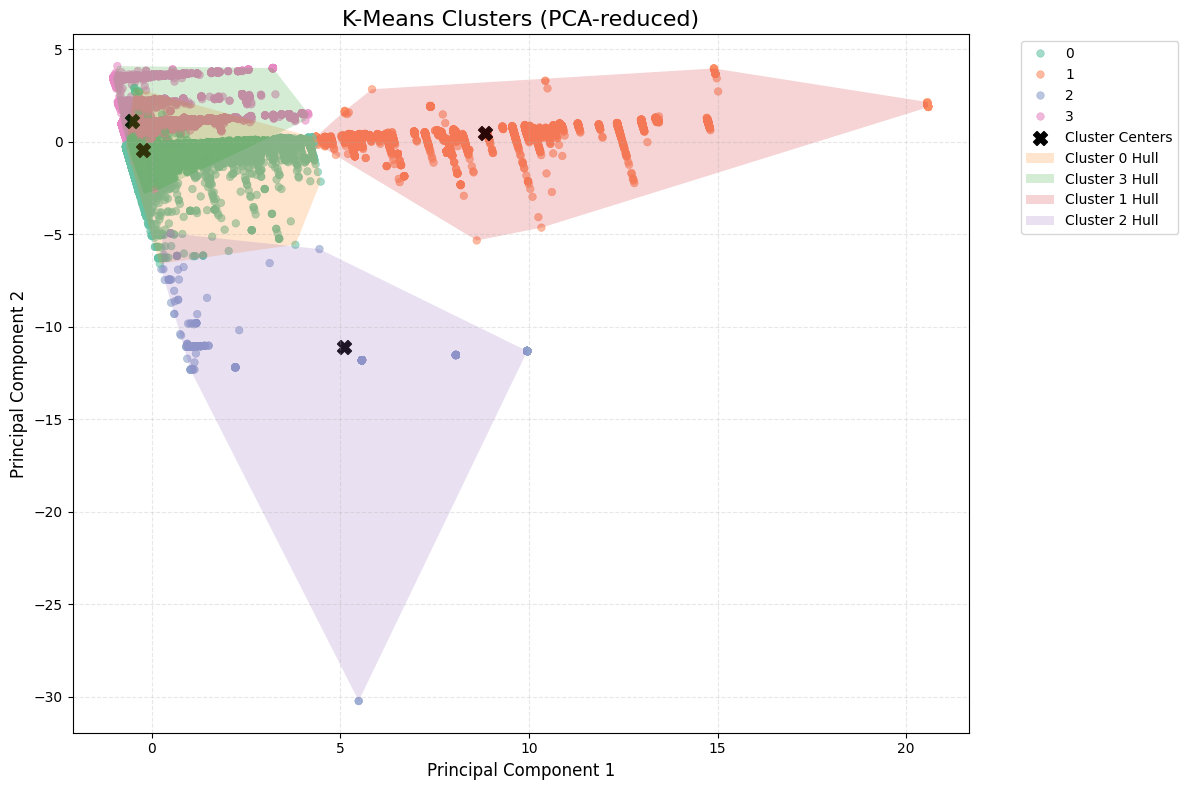


Sample records from Cluster 0:


,Room ID,Host ID,Neighbourhood,Room type,Room Price,Minimum nights,Number of reviews per month,Rooms rent by the host,Availibility,City,Country,Location
67800,38517549,56520924,Koolaupoko,0,1465,3,0.16,30,195,Hawaii,United states,"United states, Hawaii, Koolaupoko"
113199,9902932,6079156,West Village,0,300,4,2.33,1,179,New-york-city,United states,"United states, New-york-city, West Village"
167059,24715542,186810029,District 7,0,249,2,0.77,1,303,Nashville,United states,"United states, Nashville, District 7"
158072,13326649,4962900,Central Business District,0,999,2,0.13,86,360,New-orleans,United states,"United states, New-orleans, Central Business D..."
184508,12047919,248404,St. Roch,0,45,30,2.42,4,354,New-orleans,United states,"United states, New-orleans, St. Roch"



Sample records from Cluster 3:


,Room ID,Host ID,Neighbourhood,Room type,Room Price,Minimum nights,Number of reviews per month,Rooms rent by the host,Availibility,City,Country,Location
58744,39873497,41384568,Santa Monica,1,90,30,0.17,1,365,Los-angeles,United states,"United states, Los-angeles, Santa Monica"
118148,35799139,38147767,78753,1,55,3,0.39,1,337,Austin,United states,"United states, Austin, 78753"
145091,28635307,158589209,Millbrae,3,78,31,0.06,2,180,San-mateo-county,United states,"United states, San-mateo-county, Millbrae"
55243,10713346,55366398,Puna,1,45,3,0.17,2,364,Hawaii,United states,"United states, Hawaii, Puna"
232658,36208782,272330017,Larchmont,1,90,7,0.63,1,61,Los-angeles,United states,"United states, Los-angeles, Larchmont"



Sample records from Cluster 1:


,Room ID,Host ID,Neighbourhood,Room type,Room Price,Minimum nights,Number of reviews per month,Rooms rent by the host,Availibility,City,Country,Location
73126,18948228,132087088,Kihei-Makena,0,324,5,0.21,203,185,Hawaii,United states,"United states, Hawaii, Kihei-Makena"
144837,17975434,122055416,La Jolla,0,1180,1,0.14,200,314,San-diego,United states,"United states, San-diego, La Jolla"
41886,11319006,2154262,Kihei-Makena,0,359,4,0.24,285,184,Hawaii,United states,"United states, Hawaii, Kihei-Makena"
51967,37221071,15820446,Lahaina,0,235,5,0.37,210,125,Hawaii,United states,"United states, Hawaii, Lahaina"
877,24964266,100238132,Unincorporated Areas,0,165,3,0.90,111,338,Clark-county-nv,United states,"United states, Clark-county-nv, Unincorporated..."



Sample records from Cluster 2:


,Room ID,Host ID,Neighbourhood,Room type,Room Price,Minimum nights,Number of reviews per month,Rooms rent by the host,Availibility,City,Country,Location
109603,41615888,104309976,Mission Bay,0,10000,1,4.37,85,129,San-diego,United states,"United states, San-diego, Mission Bay"
23044,43413927,104309976,78701,0,10000,1,1.88,166,168,Austin,United states,"United states, Austin, 78701"
9793,40950769,71508455,"Shaw, Logan Circle",3,7000,1,0.57,7,222,Washington-dc,United states,"United states, Washington-dc, Shaw, Logan Circle"
200577,42507451,104309976,78751,0,10000,1,1.90,166,258,Austin,United states,"United states, Austin, 78751"
40680,32208003,104309976,78704,0,10000,1,4.74,166,152,Austin,United states,"United states, Austin, 78704"


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

pca = PCA(n_components=2, random_state=42)
df_visual = df_cluster.copy()
df_visual[['PCA1', 'PCA2']] = pca.fit_transform(X_scaled)

cluster_centers_pca = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='KMeans_Cluster', 
    palette='Set2', 
    data=df_visual,
    s=30,               
    alpha=0.6,
    edgecolor=None
)

plt.scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1], 
            c='black', s=100, marker='X', label='Cluster Centers')

for cluster_id in df_visual['KMeans_Cluster'].unique():
    cluster_points = df_visual[df_visual['KMeans_Cluster'] == cluster_id][['PCA1', 'PCA2']].values
    if len(cluster_points) >= 3:  # Convex hull needs at least 3 points
        hull = ConvexHull(cluster_points)
        hull_points = cluster_points[hull.vertices]
        plt.fill(hull_points[:,0], hull_points[:,1], alpha=0.2, linewidth=0, label=f'Cluster {cluster_id} Hull')

plt.title('K-Means Clusters (PCA-reduced)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(loc='best', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print 5 random records per cluster
for cluster_id in df_visual['KMeans_Cluster'].unique():
    print(f"\nSample records from Cluster {cluster_id}:")
    display(df_cleaned[df_visual['KMeans_Cluster'] == cluster_id].sample(n=min(5, len(df_visual[df_visual['KMeans_Cluster'] == cluster_id])), random_state=42))


## 4. Network Analysis

In [ ]:
# Focus on the desired cluster
cluster_number = 1  
df_clustered_hosts = df_cleaned[df_cluster['KMeans_Cluster'] == cluster_number]

print(f"Cluster {cluster_number} selected with {len(df_clustered_hosts)} listings.")


Cluster 1 selected with 4807 listings.


In [ ]:
import networkx as nx
from collections import defaultdict

host_to_neighborhoods = defaultdict(set)

for _, row in df_cleaned[df_cluster['KMeans_Cluster'] == cluster_number].iterrows():
    host_to_neighborhoods[row['Host ID']].add(row['Neighbourhood'])

G_neigh = nx.Graph()

for neighborhoods in host_to_neighborhoods.values():
    neighborhoods = list(neighborhoods)
    if len(neighborhoods) > 1:
        for i in range(len(neighborhoods)):
            for j in range(i + 1, len(neighborhoods)):
                if G_neigh.has_edge(neighborhoods[i], neighborhoods[j]):
                    G_neigh[neighborhoods[i]][neighborhoods[j]]['weight'] += 1
                else:
                    G_neigh.add_edge(neighborhoods[i], neighborhoods[j], weight=1)


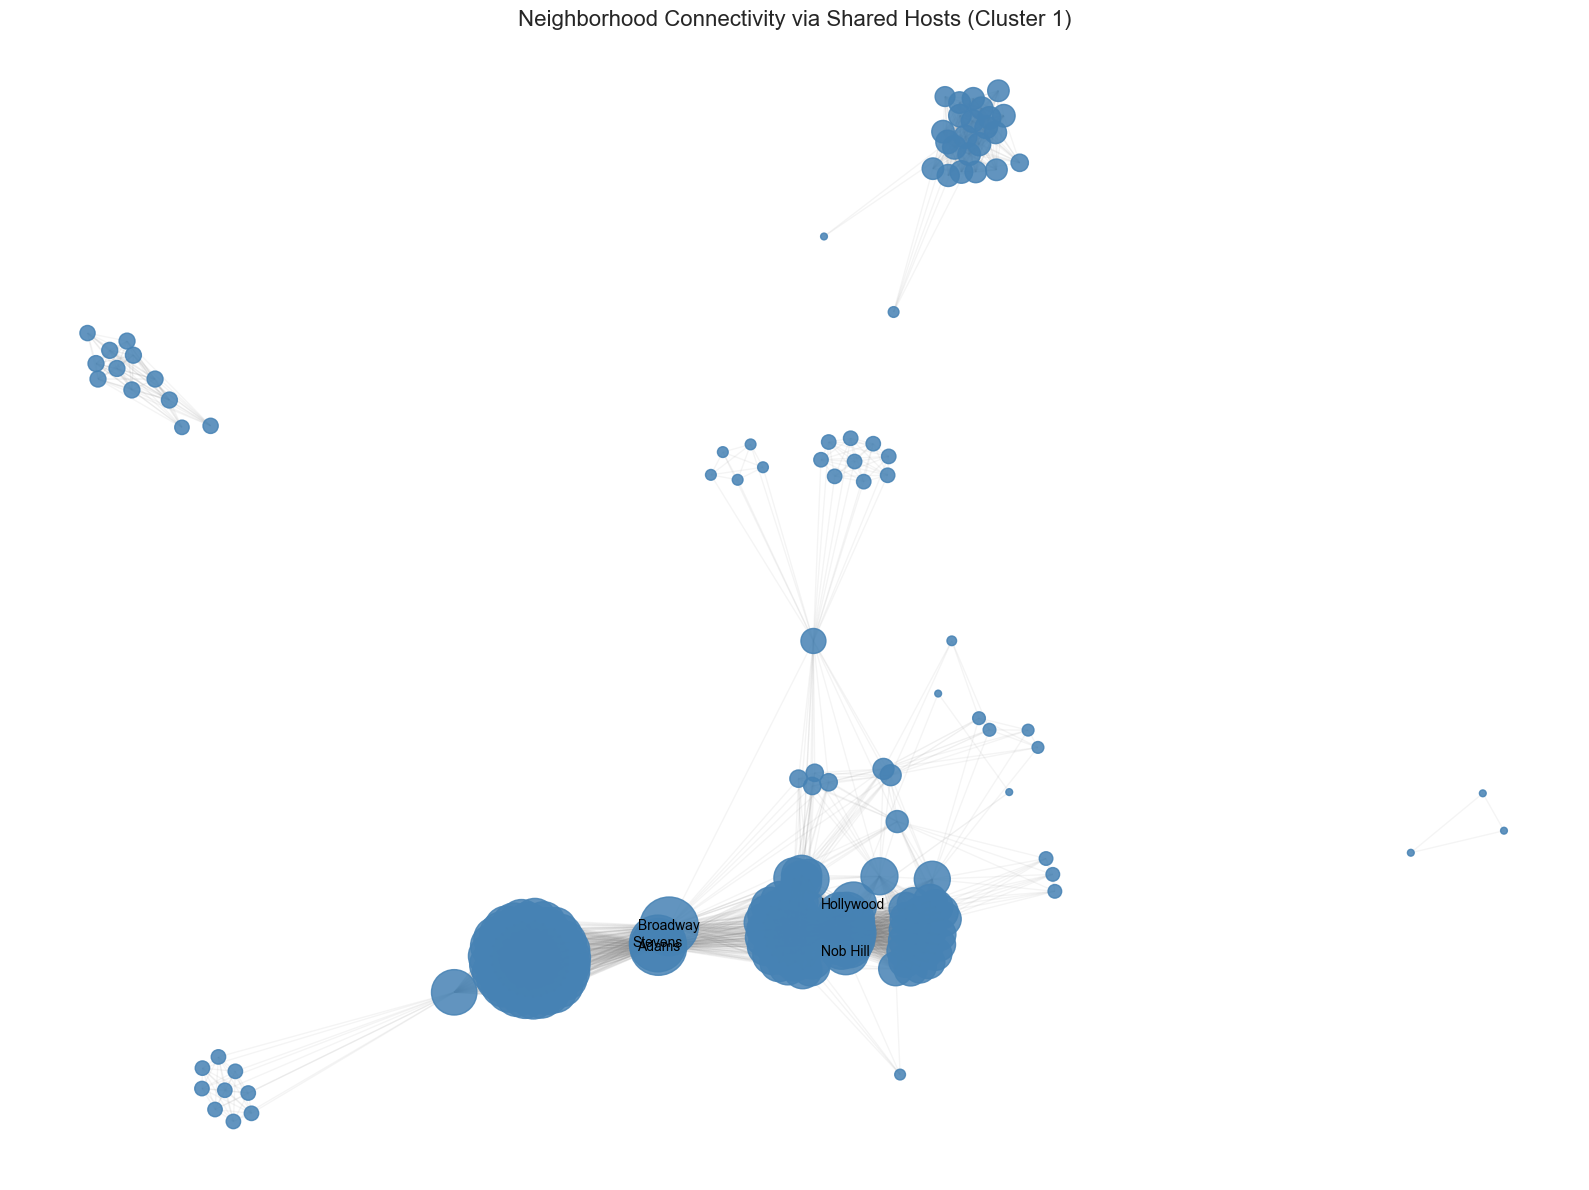

In [ ]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(G_neigh, k=0.5, iterations=150, seed=42)

degree_centrality = nx.degree_centrality(G_neigh)
node_sizes = [3000 * degree_centrality[node] for node in G_neigh.nodes()]

nx.draw_networkx_nodes(G_neigh, pos, node_size=node_sizes, node_color='steelblue', alpha=0.85)

edges = G_neigh.edges()
weights = [G_neigh[u][v]['weight'] for u, v in edges]
edge_alphas = [min(0.05 + (w / max(weights)) * 0.3, 0.4) for w in weights]

for (u, v), alpha in zip(edges, edge_alphas):
    nx.draw_networkx_edges(G_neigh, pos, edgelist=[(u, v)], width=1, alpha=alpha, edge_color='gray')

top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_labels = {node: node for node, _ in top_nodes}  # <-- FIX: use node name itself as label

nx.draw_networkx_labels(G_neigh, pos, labels=top_labels, font_size=10, font_color='black')

plt.title(f"Neighborhood Connectivity via Shared Hosts (Cluster {cluster_number})", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.graph_objects as go

node_x = []
node_y = []
node_text = []
node_size = []

for node in G_neigh.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_size.append(10 + 50 * degree_centrality[node])
    node_text.append(f"{node}<br>Centrality: {degree_centrality[node]:.3f}")

edge_x = []
edge_y = []
for u, v in G_neigh.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'))

fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    textposition="top center",
    marker=dict(
        size=node_size,
        color='steelblue',
        line=dict(width=1, color='darkblue'),
        opacity=0.8
    ),
    text=[label if label in top_labels else "" for label in G_neigh.nodes()],
    hovertext=node_text,
    hoverinfo='text'
))

fig.update_layout(
    title=f"Neighborhood Network (Interactive) - Cluster {cluster_number}",
    title_x=0.5,
    showlegend=False,
    margin=dict(l=20, r=20, t=40, b=20),
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()


In [ ]:
# Degree centrality shows most interconnected neighborhoods
neigh_centrality = nx.degree_centrality(G_neigh)

top_neigh = sorted(neigh_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Neighborhoods (by degree centrality):")
for neigh, centrality in top_neigh:
    print(f"{neigh}: {centrality:.3f}")


Top Neighborhoods (by degree centrality):
Broadway: 0.592
Stevens: 0.556
Adams: 0.556
Hollywood: 0.368
Nob Hill: 0.364
Western Addition: 0.360
Downtown/Civic Center: 0.360
Downtown: 0.360
Beverly Grove: 0.360
South of Market: 0.360
